# Evidencia 01 – Minería de datos

**Curso:** TC2034 - Modelación del aprendizaje con inteligencia artificial

**Integrantes:** 
Erandi Shirel Miranda Barajas - A01660902, 
David Leonardo García Hernández - A01661018, 
Sebastián Ángel Pedraza - A01663610

# Algunas propuestas

## Nosotros elegimos este dataset:
**Heart Disease - Enfermedad cardíaca**
Dónde obtenerlo: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset

Descripción: Datos clínicos de pacientes (edad, colesterol, presión arterial, etc.). Variable objetivo: presencia (1) o ausencia (0) de enfermedad cardíaca.

Lo que puedes obtener:

Predecir riesgo de enfermedad cardíaca.

Identificar factores de riesgo más relevantes.


**Wine - Clasificación de vinos**
Wine - Clasificación de vinos
Dónde obtenerlo: desde sklearn.datasets.load_wine()

Descripción: 178 ejemplos de vinos de 3 cultivares diferentes, con 13 características químicas.

Lo que puedes obtener:

Clasificar un vino en una de las tres categorías.

Reducir dimensionalidad (opcional) y ver cómo afecta a los modelos.

Comparar modelos multiclase.


**Pima Indians Diabetes - Diabetes en mujeres**

Dónde obtenerlo: https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database

Descripción: Datos de mujeres de ascendencia Pima, con características como glucosa, presión arterial, edad, etc. Variable objetivo: diabetes (0/1).

Lo que puedes obtener:

Predecir si una paciente tiene diabetes.

Identificar los factores más influyentes (glucosa, IMC, etc.).

Manejar valores atípicos o nulos (algunos atributos tienen ceros que no tienen sentido biológico).

**Spam or Not Spam - Clasificación de correos electrónicos**

Dónde obtenerlo: https://www.kaggle.com/datasets/balaka18/email-spam-classification-dataset-csv

Descripción: Características sobre frecuencia de palabras, caracteres especiales, etc. Variable objetivo: spam (1) o no spam (0).

Lo que puedes obtener:

Clasificar correos como spam o no spam.

Aplicar Naïve Bayes (especialmente bueno en texto).

Comparar con regresión logística y Random Forest.

## 1. Carga de librerías

In [56]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

## 2. Preprocesamiento del dataset (Heart disease)

In [57]:
# Cargar tu dataset (ejemplo con Titanic, pero cámbialo)
url = "heart.csv"
df = pd.read_csv(url)

# Si tu dataset está en otro formato, usa la función correspondiente (pd.read_excel, etc.)

# Mostrar primeras filas
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [58]:
# 1. Información general
df.info()
df.describe()



# 2. Identificar y tratar nulos
print(df.isnull().sum())
# Aplicar imputación o eliminación según corresponda
# EN ESTE DATASET NO HAY NULOS



# 3. Identificar y tratar outliers (opcional, depende del dataset)
columnas_outliers = ['chol', 'trestbps', 'thalach', 'oldpeak']

display('CONTEO DE OUTLIERS POR COLUMNA')
for col in columnas_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    
    conteo = len(df[(df[col] < limite_inf) | (df[col] > limite_sup)])
    display(f"Variable '{col}': {conteo} outliers detectados.")

display("----------------------------------------------------------------")
    
display('TABLAS DE VALORES VS LÍMITES')
for col in columnas_outliers:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    
    limite_inf = q1 - 1.5 * iqr
    limite_sup = q3 + 1.5 * iqr
    
    filtro_outliers = df[(df[col] < limite_inf) | (df[col] > limite_sup)].copy()
    
    if not filtro_outliers.empty:
        display(f"Tabla de outliers de {col.upper()}")
        display(f"Límites calculados: Inferior = {limite_inf:.2f} & Superior = {limite_sup:.2f}")
        
        filtro_outliers['Valor_Outlier'] = filtro_outliers[col]
        filtro_outliers['Límite_Referencia'] = filtro_outliers['Valor_Outlier'].apply(
            lambda x: limite_sup if x > limite_sup else limite_inf)
        filtro_outliers['Tipo_Outlier'] = filtro_outliers['Valor_Outlier'].apply(
            lambda x: 'Superior Extremo' if x > limite_sup else 'Inferior Extremo')
        
        columnas_tabla = ['Valor_Outlier', 'Límite_Referencia', 'Tipo_Outlier', 'age', 'target']
        display(filtro_outliers[columnas_tabla])
        display("----------------------------------------------------------------") 



# 4. Codificar variables categóricas
df = pd.get_dummies(df, columns=['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'thal'], drop_first=True)
df = df.astype(int)



# 5. Separar características (X) y variable objetivo (y)
y = df['target']
X = df[['age', 'trestbps', 'chol', 'thalach', 'oldpeak', 'ca','sex_1', 'cp_1', 'cp_2', 'cp_3','fbs_1', 
    'restecg_1', 'restecg_2','exang_1','slope_1', 'slope_2', 'thal_1', 'thal_2', 'thal_3']]



# 6. Escalar características numéricas (opcional, pero recomendado para regresión logística, perceptrón, etc.)
from sklearn.preprocessing import StandardScaler

X_escalado = X.copy()
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
scaler = StandardScaler()
X_escalado[num_cols] = scaler.fit_transform(X_escalado[num_cols])



# 7. Dividir en entrenamiento y prueba
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_escalado, y, test_size=0.15, random_state=42)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


'CONTEO DE OUTLIERS POR COLUMNA'

"Variable 'chol': 16 outliers detectados."

"Variable 'trestbps': 30 outliers detectados."

"Variable 'thalach': 4 outliers detectados."

...

'----------------------------------------------------------------'

'Tabla de outliers de OLDPEAK'

'Límites calculados: Inferior = -2.70 & Superior = 4.50'

,Valor_Outlier,Límite_Referencia,Tipo_Outlier,age,target
54,5.6,4.5,Superior Extremo,55,0
55,5.6,4.5,Superior Extremo,55,0
69,6.2,4.5,Superior Extremo,62,0
393,6.2,4.5,Superior Extremo,62,0
526,6.2,4.5,Superior Extremo,62,0
613,5.6,4.5,Superior Extremo,55,0
833,5.6,4.5,Superior Extremo,55,0


'----------------------------------------------------------------'

## 3. Análisis exploratorio (EDA)

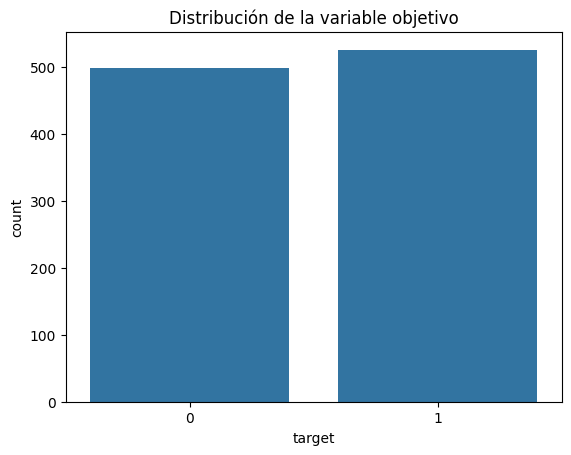

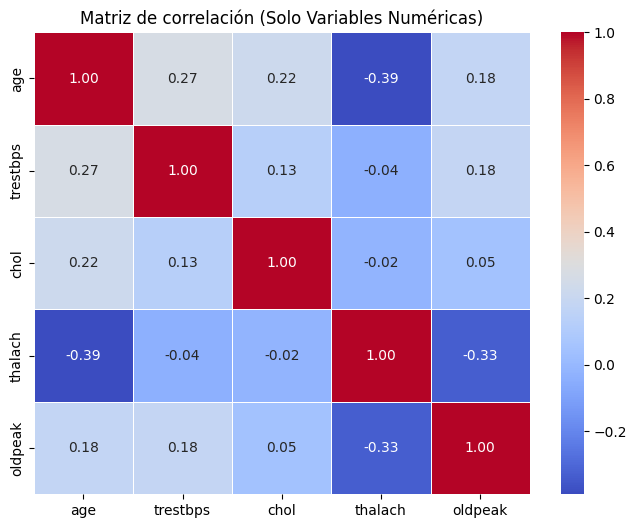

In [59]:
sns.countplot(x=y)
plt.title('Distribución de la variable objetivo')
plt.show()

num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
corr = X[num_cols].corr()

plt.figure(figsize=(8,6)) 
annot=True
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matriz de correlación (Solo Variables Numéricas)')
plt.show()

## 4. Modelado

In [60]:
# Modelo 1: Regresión logística
log_reg = LogisticRegression(random_state=42, max_iter=1000)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
y_proba_lr = log_reg.predict_proba(X_test)[:, 1]

# Modelo 2: Random Forest
rf = RandomForestClassifier(n_estimators=1, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:, 1]

# Modelo 3: Naive Bayes
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
y_proba_nb = nb.predict_proba(X_test)[:, 1]


## 5. Evaluación

In [61]:
def evaluar_modelo(y_true, y_pred, y_proba, nombre):
    print(f"--- {nombre} ---")
    print(f"Exactitud: {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precisión: {precision_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"Recall: {recall_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"F1: {f1_score(y_true, y_pred, zero_division=0):.4f}")
    print(f"AUC: {roc_auc_score(y_true, y_proba):.4f}")
    print("Matriz de confusión:")
    print(confusion_matrix(y_true, y_pred))
    print("-"*30)

evaluar_modelo(y_test, y_pred_lr, y_proba_lr, 'Regresión Logística')
evaluar_modelo(y_test, y_pred_rf, y_proba_rf, 'Random Forest')
evaluar_modelo(y_test, y_pred_nb, y_proba_nb, 'Naive Bayes')

--- Regresión Logística ---
Exactitud: 0.8247
Precisión: 0.7816
Recall: 0.8947
F1: 0.8344
AUC: 0.9049
Matriz de confusión:
[[59 19]
 [ 8 68]]
------------------------------
--- Random Forest ---
Exactitud: 0.9675
Precisión: 0.9733
Recall: 0.9605
F1: 0.9669
AUC: 0.9674
Matriz de confusión:
[[76  2]
 [ 3 73]]
------------------------------
--- Naive Bayes ---
Exactitud: 0.8182
Precisión: 0.7927
Recall: 0.8553
F1: 0.8228
AUC: 0.8838
Matriz de confusión:
[[61 17]
 [11 65]]
------------------------------


### Curvas ROC comparativas

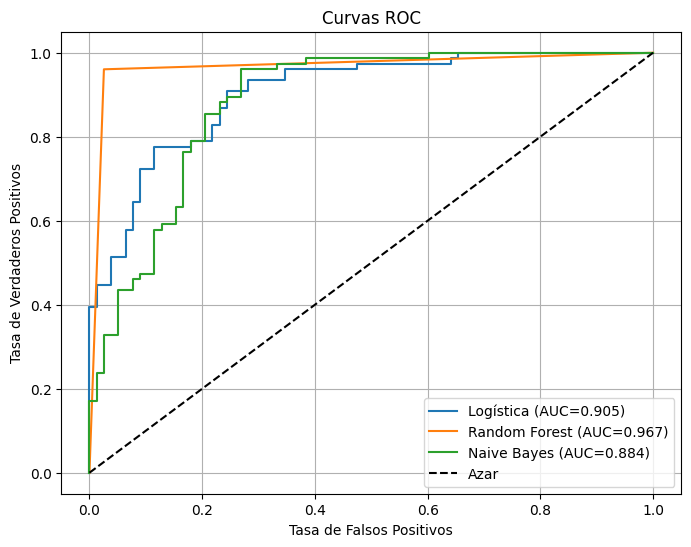

In [62]:
plt.figure(figsize=(8,6))
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logística (AUC={auc_lr:.3f})')

fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')

fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)
auc_nb = roc_auc_score(y_test, y_proba_nb)
plt.plot(fpr_nb, tpr_nb, label=f'Naive Bayes (AUC={auc_nb:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Azar')
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curvas ROC')
plt.legend()
plt.grid()
plt.show()

## 6. Preguntas de reflexión

**1.** ¿Cuál de los modelos obtuvo mejor AUC? ¿Qué significado tiene ese valor?

<ins>El Random Forest fue el modelo con mejor AUC, con un valor de 0.967, lo cual significa que hay un 96.7% de probabilidad de que el modelo clasifique correctamente entre un paciente que tiene una enfermedad cardíaca y uno que está sano. <ins>

**2.** En el contexto de tu problema, ¿es más importante la precisión o el recall? Justifica.

<ins>En nuestro caso, sería más importante recall, ya que en el área médica se desea obtener el menor número de falsos negativos, traduciéndose en que se predice en no enfermedad pero en realidad sí hay.<ins>

**3.** ¿Qué limitaciones encuentras en tu modelo (datos desbalanceados, falta de características, overfitting)? ¿Cómo podrías mejorarlo?

<ins> Probamos tres modelos: Regresión Logística, Random Forest y Naive Bayes, siendo Random Forest el que nos dio los mejores resultados de los tres. Sin embargo, una limitación importante es que el dataset no incluye todos los factores médicos y de estilo de vida que podrían influir en una enfermedad cardíaca, como antecedentes familiares, actividad física, estrés o consumo de tabaco.Además, desde el punto de vista técnico, una métrica tan alta (o demasiado perfecta) en Random Forest presenta el riesgo de overfitting, es decir, que el modelo se memorice los datos de entrenamiento. Para mejorar eso, se podría expandir el dataset con más variables clínicas, usar validación cruzada y ajustar algunos hiperparámetros del modelo.<ins>

**4.** ¿Qué aprendiste al realizar este proyecto? Menciona al menos dos conceptos que se reforzaron.

<ins>En este proyecto aprendimos que la minería de datos no solo consiste en entrenar modelos, sino que también es analizar la información. Reforzamos conceptos como limpieza de datos, codificación de variables categóricas, escalado de variables numéricas y separación entre datos de entrenamiento y prueba. También aprendimos a comparar modelos usando métricas como exactitud, precisión, recall, F1 y AUC, y entendimos que en un problema médico el recall es muy importante porque ayuda a reducir los falsos negativos.<ins> 

# Evidencia 02 - Aprendizaje no supervisado

## Parte 1: Clustering no supervisado (k-means)

### Carga y preprocesamiento

In [63]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [64]:
# Cargar datos
X_ns = X_escalado.copy()
y_true = y.copy()
X_scaled_ns = X_ns.values 

print("Datos listos sin etiquetas.")

Datos listos sin etiquetas.


### Método del codo (inercia)

k=1: inercia = 8547.496
k=2: inercia = 6970.498
k=3: inercia = 6367.836
k=4: inercia = 5921.405
k=5: inercia = 5541.124
k=6: inercia = 5297.656
k=7: inercia = 5064.829
k=8: inercia = 4918.096
k=9: inercia = 4755.821
k=10: inercia = 4627.268


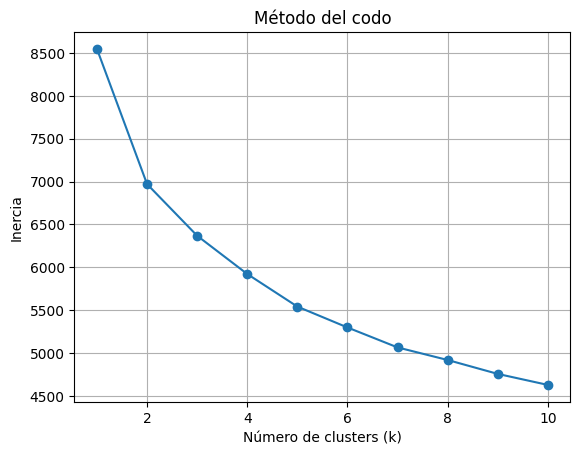

In [65]:
inercia = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled_ns)
    inertia = kmeans.inertia_
    inercia.append(inertia)
    print(f"k={k}: inercia = {inertia:.3f}")


plt.plot(k_range, inercia, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del codo')
plt.grid()
plt.show()

### Coeficiente de silueta

k=2: silhouette = 0.177
k=3: silhouette = 0.124
k=4: silhouette = 0.126
k=5: silhouette = 0.144
k=6: silhouette = 0.142


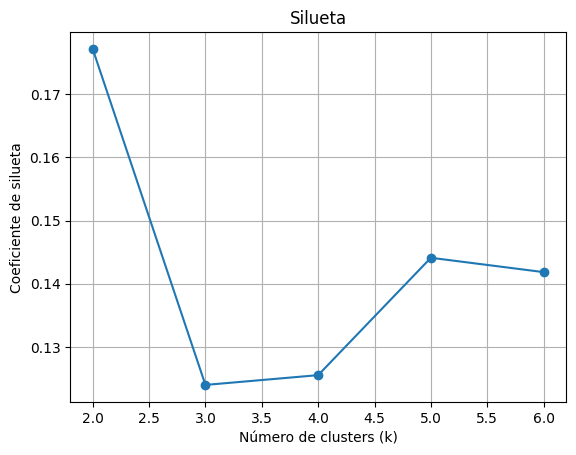

In [66]:
silhouette_scores = []
k_range_s = range(2, 7)

for k in k_range_s:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled_ns)
    # COMPLETAR: calcular silhouette_score
    score = silhouette_score(X_scaled_ns, labels)
    silhouette_scores.append(score)
    print(f"k={k}: silhouette = {score:.3f}")

plt.plot(k_range_s, silhouette_scores, marker='o')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Coeficiente de silueta')
plt.title('Silueta')
plt.grid()
plt.show()

### Aplicar k-means con el mejor k

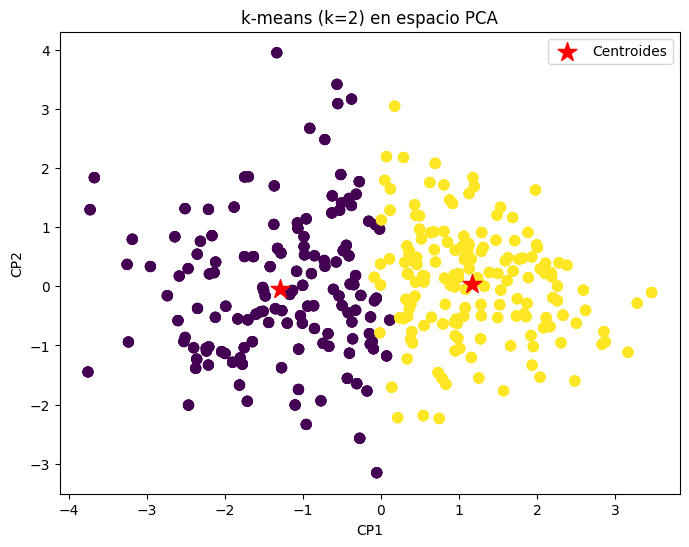

[0.26579599 0.14015698]


In [67]:
best_k = 2  
kmeans_final = KMeans(n_clusters=best_k, random_state=42, n_init=10)
# COMPLETAR: entrenar y obtener etiquetas
labels = kmeans_final.fit_predict(X_scaled_ns)

# Reducir a 2D con PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled_ns)

plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=labels, cmap='viridis', s=50)

centroids_pca = pca.transform(kmeans_final.cluster_centers_)
plt.scatter(centroids_pca[:,0], centroids_pca[:,1], marker='*', s=200, c='red', label='Centroides')
plt.xlabel('CP1')
plt.ylabel('CP2')
plt.title(f'k-means (k={best_k}) en espacio PCA')
plt.legend()
plt.show()
print(pca.explained_variance_ratio_)

### Intepretación de los clusters

In [68]:
df_clusters = pd.DataFrame(X_scaled_ns, columns=X_ns.columns)
df_clusters['cluster'] = labels
# COMPLETAR: calcular medias por cluster
cluster_summary = df_clusters.groupby('cluster').mean()
print(cluster_summary)

              age  trestbps      chol   thalach   oldpeak        ca     sex_1  \
cluster                                                                         
0        0.608592  0.285592  0.228365 -0.679440  0.532428  1.166324  0.702259   
1       -0.550900 -0.258520 -0.206717  0.615032 -0.481956  0.381041  0.689591   

             cp_1      cp_2      cp_3     fbs_1  restecg_1  restecg_2  \
cluster                                                                 
0        0.055441  0.186858  0.082136  0.190965   0.357290   0.030801   
1        0.260223  0.358736  0.068773  0.111524   0.630112   0.000000   

          exang_1   slope_1   slope_2    thal_1    thal_2    thal_3  
cluster                                                              
0        0.542094  0.718686  0.184805  0.094456  0.347023  0.558522  
1        0.150558  0.245353  0.704461  0.033457  0.697026  0.256506  


El análisis de las medias de características por clúster confirma que el modelo logró segmentar a la población en dos perfiles bastante evidentes y lógicos. Por un lado, el "Cluster 0" podría llamarse "Pacientes de alto riesgo cardiovascular" o "Pacientes enfermos latentes" y agrupa a aquellos de edad avanzada, niveles elevados de presión arterial y colesterol, una notable depresión del segmento ST y una propensión a sufrir angina inducida por ejercicio. Por el contrario, el "Cluster 1" podría llamarse "Pacientes estables" o "Pacientes no enfermos", pues en este perfil se concentra la población más joven y saludable del estudio, cuyas características son: presión controlada, colesterol y niveles de fatiga por esfuerzo muy debajo de la media general, buena respuesta cardíaca en pruebas físicas, entre otras.

## Parte 2: Red neuronal multicapa (clasificación supervisada)

### Funciones de activación importantes

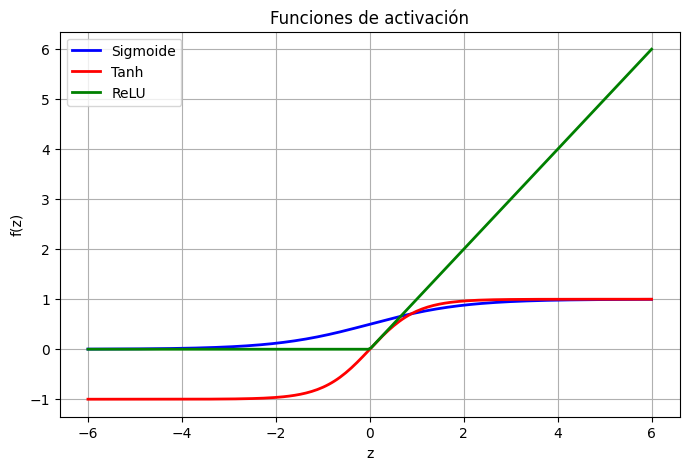

In [69]:
z = np.linspace(-6, 6, 200)
sigmoid = 1 / (1 + np.exp(-z))
tanh = np.tanh(z)
relu = np.maximum(0, z)

plt.figure(figsize=(8,5))
plt.plot(z, sigmoid, label='Sigmoide', color='blue', lw=2)
plt.plot(z, tanh, label='Tanh', color='red', lw=2)
plt.plot(z, relu, label='ReLU', color='green', lw=2)
plt.xlabel('z')
plt.ylabel('f(z)')
plt.title('Funciones de activación')
plt.grid(True)
plt.legend()
plt.show()

Dataset: Dígitos manuscritos

In [70]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import plotly.express as px

ModuleNotFoundError: No module named 'tensorflow.python'

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Cargar dataset
X_neu = X_escalado.copy()
y_neu = y.copy()

# Normalizar características a rango 0-1
X_neu = X_neu / 16.0

# Dividir en entrenamiento y prueba
X_train_neu, X_test_neu, y_train_neu, y_test_neu = train_test_split(X_neu, y_neu, test_size=0.15, random_state=42)

print(f"Entrenamiento: {X_train_neu.shape}, Prueba: {X_test_neu.shape}")

Entrenamiento: (871, 19), Prueba: (154, 19)


### Construcción con Keras

In [ ]:
model = keras.Sequential([
    layers.Input(shape=(19,)),
    layers.Dense(64, activation='relu', name='hidden1'),
    layers.Dense(32, activation='relu', name='hidden2'),
    layers.Dense(1, activation='sigmoid', name='output')
])

model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden1 (Dense)                 │ (None, 64)             │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,393 (13.25 KB)

 Trainable params: 3,393 (13.25 KB)

 Non-trainable params: 0 (0.00 B)

### Entrenamiento

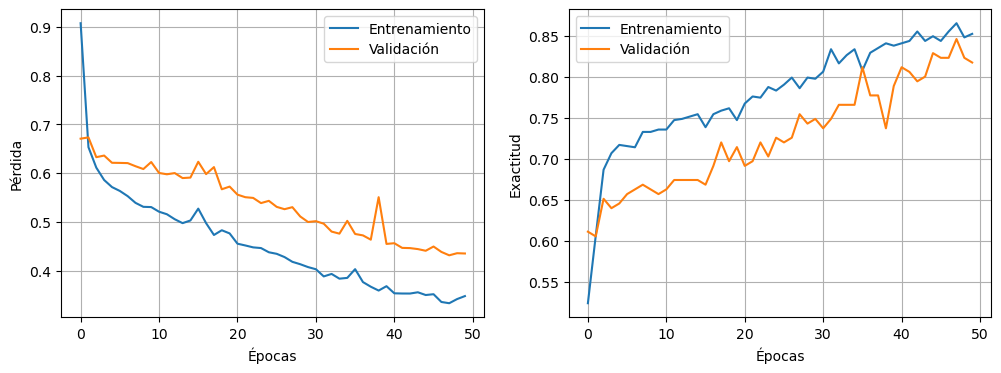

In [ ]:
history = model.fit(X_train_neu, y_train_neu,
                    validation_split=0.2,
                    epochs=50,
                    batch_size=32, 
                    verbose=0)

# Graficar pérdida y exactitud
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,4))

ax1.plot(history.history['loss'], label='Entrenamiento')
ax1.plot(history.history['val_loss'], label='Validación')
ax1.set_xlabel('Épocas')
ax1.set_ylabel('Pérdida')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['accuracy'], label='Entrenamiento')
ax2.plot(history.history['val_accuracy'], label='Validación')
ax2.set_xlabel('Épocas')
ax2.set_ylabel('Exactitud')
ax2.legend()
ax2.grid(True)

plt.show()

### Evaluación

In [ ]:
test_loss, test_acc = model.evaluate(X_test_neu, y_test_neu, verbose=0)
print(f"Exactitud en prueba: {test_acc:.4f}")

# Predecir clases y probabilidades
y_proba_neu = model.predict(X_test_neu, verbose=0).ravel()
y_pred_neu = (y_proba_neu >= 0.5).astype(int)

# Mostrar algunas predicciones
display(pd.DataFrame({
    'Real': y_test_neu.reset_index(drop=True).head(10),
    'Predicción': y_pred_neu[:10],
    'Probabilidad': y_proba_neu[:10]
}))

Exactitud en prueba: 0.8377


,Real,Predicción,Probabilidad
0,1,1,0.915007
1,1,1,0.773948
2,0,0,0.063957
3,1,1,0.926300
4,0,0,0.089196
5,1,0,0.454072
6,0,0,0.055006
7,0,0,0.014458
8,1,1,0.825418
9,0,0,0.091161


In [ ]:
# Importar métricas necesarias
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Accuracy
acc = accuracy_score(y_test_neu, y_pred_neu)

# Precision, Recall y F1
precision = precision_score(y_test_neu, y_pred_neu, zero_division=0)
recall = recall_score(y_test_neu, y_pred_neu, zero_division=0)
f1 = f1_score(y_test_neu, y_pred_neu, zero_division=0)

# AUC
auc = roc_auc_score(y_test_neu, y_proba_neu)

# Matriz de confusión
cm = confusion_matrix(y_test_neu, y_pred_neu)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1: {f1:.4f}")
print(f"AUC: {auc:.4f}")

fig = px.imshow(
    cm,
    labels=dict(x='Predicción', y='Real'),
    x=['No enfermo (0)', 'Enfermo (1)'],
    y=['No enfermo (0)', 'Enfermo (1)'],
    color_continuous_scale='Blues',
    text_auto=True,
    title='Matriz de Confusión: Red Neuronal de "Heart Disease"'
)

fig.update_layout(
    height=500,
    width=600,
    xaxis_title='Predicción',
    yaxis_title='Real'
)

fig.show()


Accuracy: 0.8377
Precision: 0.7931
Recall: 0.9079
F1: 0.8466
AUC: 0.9057


### Comparación del rendimiento de la MLP con los mejores modelos de la Evidencia 01 y discusión de la significancia de la red neuronal 

Al comparar la red neuronal con los modelos de la Evidencia 01, se concluye que la red neuronal no aporta una mejora significativa en este contexto. Mientras que la MLP alcanzó una exactitud del 82% en validación, Random Forest logró una del 96.75%, además de que sus otras métricas son: precisión (97.33%), recall (96.05%) y AUC (0.9674). 

## Reflexión y conclusiones
1. ¿Los clusters encontrados con k-means se corresponden con alguna de las clases reales? ¿Tienen sentido en el dominio del problema?

Sí. Al elegir k = 2, el algoritmo separó los datos de forma binaria, donde cada división corresponde directamente con las dos clases reales del dataset: pacientes no enfermos (0) y pacientes con enfermedades cardíacas (1). Este agrupamiento hace sentido en el contexto del problema, ya que en la medicina cardiovascular, la prioridad es la clasificación binaria (sano vs. enfermo) para la toma de decisiones clínicas.

2. ¿La red neuronal superó a los modelos tradicionales? ¿Por qué (o por qué no)?

No, porque el Random Forest demostró un rendimiento extremadamente superior. Mientras que la red neuronal alcanzó una exactitud del 82% en validación, el Random Forest logró un 96.75%, superándolo también en todas las otras métricas de precisión, recall (96.05%) y AUC (0.9674). La razón de este comportamiento se debe a que el dataset de "Heart Disease" tiene variables bien definidas y eso favorece a los modelos de árboles de decisión. Por otro lado, las redes neuronales requieren de volúmenes masivos de datos, por lo que un modelo tradicional correctamente entrenado puede capturar mejor los patrones y con un menor riesgo de error.

3. ¿Qué limitaciones observan en k-means (forma de los clusters, sensibilidad a outliers) y en la MLP (cantidad de datos, overfitting)?

En relación con K-means, existen dos principales limitaciones: forma de los clusters y sensibilidad a outliers. En el primer punto, K-means asume que los grupos son esféricos, por lo que si los datos médicos reales tienen formas irregulares, la separación se vuelve forzada. Acerca del segundo, si hay un paciente con valores extremadamente atípicos (como un colesterol exageradamente alto) puede mover el centroide y alterar la agrupación de los demás. 

Acerca de las limitaciones de la MLP, las pocas dinámicas de este dataset hacen que el modelo llegue a un punto donde no puede aprender más, pues para ello necesita muchísimo más datos. Asimismo, existe un riesgo de sobreajuste. Aunque las gráficas de pérdida y exactitud mostraron resultados favorables, las MLP siempre corren el riesgo de memorizar los datos de entrenamiento en lugar de aprender.


4. ¿Qué recomendaciones prácticas darían si este modelo se usara en un entorno real (por ejemplo, en un hospital, en una empresa)?

La principal recomendación es mantener siempre al humano como la decisión final, es decir, el sistema solo debe funcionar como una herramienta de segunda opinión médica y jamás para dar diagnósticos definitivos. Asimismo, es importante monitorear y reducir al mínimo los falsos negativos, ya que, aunque el modelo solo registró 7 casos en la prueba, en el contexto clínico esto representa a personas enfermas que serían dadas de alta por error. Para solucionar esto, se sugiere tener un umbral de decisión mejor definido en la función Sigmoide de la capa de salida. De esta manera, se prioriza la detección de la enfermedad para reducir los falsos negativos a cero.